# JourneyGraph — LLM Pipeline Demo

**Prerequisites**: `.env` at the project root with `ANTHROPIC_API_KEY`, `NEO4J_URI`, `NEO4J_USER`, `NEO4J_PASSWORD` set. Neo4j running.

**Install**: `uv sync --extra demo`

---

This notebook walks through the full natural-language query pipeline end-to-end:

| Step | Component | What it does |
|---|---|---|
| 1 | **Planner** | Classifies domain, selects execution path, extracts anchor entities |
| 2 | **Anchor Resolver** | Maps entity strings to Neo4j node IDs via full-text index |
| 3a | **Subgraph Builder** | Hop-expands anchor nodes into a contextual subgraph |
| 3b | **Text-to-Cypher** | Generates and validates a Cypher query; up to 3 self-correcting attempts |
| 4 | **Narration Agent** | Produces the final plain-English answer from query results or graph context |
| + | **Agentic Pipeline** | Same question via dynamic tool-calling loop (Claude function calls) |

---
## Setup

Initialises the shared pipeline components used across all questions below.
The `SliceRegistry` validates YAML domain slices against the live graph before any LLM call is made.

In [11]:
import sys
from pathlib import Path

_cwd = Path().resolve()
_root = next(
    (p for p in [_cwd, *_cwd.parents] if (p / "pyproject.toml").exists()), None
)
if _root is None:
    raise RuntimeError("Could not find project root — no pyproject.toml in CWD or any parent.")
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src.common.config import get_llm_config
from src.common.neo4j_tools import Neo4jManager
from src.llm.narration_agent import NarrationAgent
from src.llm.planner import Planner
from src.llm.slice_registry import SliceRegistry
from demos.pipeline_demo import (
    display_model_info,
    run_and_display,
    # Q1 step-by-step helpers
    display_question_header,
    display_planner_step,
    display_anchor_step,
    display_subgraph_step,
    display_t2c_step,
    display_narration_step,
    display_agentic_step,
    display_comparison_todo,
    run_question,
    visualize_subgraph,
)

llm_config = get_llm_config()
db = Neo4jManager()
registry = SliceRegistry(db, strict=False)
planner = Planner(registry, llm_config, strict=False)
narration_agent = NarrationAgent(llm_config)

print("Neo4j connected")
print(f"SliceRegistry domains: {registry.domains()}")
print("Planner and NarrationAgent ready")

Neo4j connected
SliceRegistry domains: ['accessibility', 'delay_propagation', 'transfer_impact']
Planner and NarrationAgent ready


---
## Model & Configuration

In [12]:
display_model_info(llm_config)

╔════════════════════════════════════════════════════════╗
║  Model       : claude-haiku-4-5-20251001                ║
║  Provider    : anthropic                                ║
║  Token budget: 512 (pipeline) / 1024 (narration)        ║
╚════════════════════════════════════════════════════════╝


---
## Questions

Three sample questions covering all three pipeline domains and both execution paths.

In [13]:
USER_QUERIES = [
    # Q1 — transfer_impact domain, text2cypher path (precise count query)
    "How many trips were cancelled on the Red Line yesterday?",

    # Q2 — TODO: replace with your second question
    "Which stations are most affected by the current delay on the Blue Line?",

    # Q3 — TODO: replace with your third question
    "Is the elevator at Metro Center currently out of service?",
]

for i, q in enumerate(USER_QUERIES, 1):
    print(f"  Q{i}: {q}")

  Q1: How many trips were cancelled on the Red Line yesterday?
  Q2: Which stations are most affected by the current delay on the Blue Line?
  Q3: Is the elevator at Metro Center currently out of service?


---
---
# Question 1 — Full Walkthrough

> *"How many trips were cancelled on the Red Line yesterday?"*

This section shows every pipeline stage in detail. Questions 2 and 3 use the same
stages internally but surface only the outputs.

---
## Q1 · Step 1: Planner

A single LLM call performs three sub-tasks simultaneously:
- **Domain classification** — which knowledge domain applies (`transfer_impact`, `delay_propagation`, `accessibility`)
- **Path routing** — `text2cypher` for precise counts/lookups, `subgraph` for topology, `both` when needed
- **Anchor extraction** — station names, route names, dates pulled from the query

JSON parse failure triggers one automatic retry with a corrective nudge, then degrades to `text2cypher` with empty anchors.

In [14]:
q1 = USER_QUERIES[0]
print(f"Query: {q1!r}")

q1_planner_output = planner.run(q1)
display_planner_step(q1_planner_output)

Query: 'How many trips were cancelled on the Red Line yesterday?'
── Step 1 · Planner ─────────────────────────────────────
  domain         : 'transfer_impact'
  path           : 'text2cypher'
  path_reasoning : 'This is a specific count query asking for a numeric result (number of cancelled trips) filtered by route and date.'
  anchor_notes   : "Red Line resolved as a named WMATA line; 'yesterday' extracted as a relative date reference."
  use_gds        : False
  anchors:
    routes         : ['Red Line']
    stations       : []
    dates          : ['yesterday']
    pathway_nodes  : []
    levels         : []


---
## Q1 · Step 2: Anchor Resolution

Maps the Planner's anchor strings to Neo4j node IDs:
- **Phase 1** — Full-text index lookup, generates candidate nodes per mention
- **Phase 2** — Disambiguation (`TopK` by default; `TypeWeightedCoherence` when `candidate_limit > 1`)
- Relative dates (`"yesterday"`, `"last Tuesday"`) are normalised to `YYYYMMDD`

In [15]:
from datetime import UTC, datetime
from src.llm.anchor_resolver import AnchorResolver

q1_invocation_time = datetime.now(UTC)
q1_resolver = AnchorResolver(db=db, invocation_time=q1_invocation_time)
q1_resolutions = q1_resolver.resolve(q1_planner_output.anchors)

display_anchor_step(q1_resolutions)


── Step 2 · Anchor Resolution ───────────────────────────
  'Red Line'                     → ['RED']
  'yesterday'                    → ['20260412']


---
## Q1 · Step 3a: Subgraph Builder

Runs only when the Planner selects `subgraph` or `both`.

- **HopExpander** — bidirectional hop expansion from anchor nodes, constrained by domain-specific `DomainExpansionConfig`
- **ContextSerializer** — serialises to a text block capped at 2,000 tokens (`tiktoken cl100k_base`)
- The raw node+edge graph is rendered below for visualisation

In [16]:
from src.llm.hop_expander import HopExpander
from src.llm.subgraph_builder import SubgraphBuilder

q1_subgraph_output = None
q1_raw_subgraph = None

if q1_planner_output.path in {"subgraph", "both"}:
    expander = HopExpander(db=db)
    q1_raw_subgraph = expander.expand(q1_resolutions, q1_planner_output.domain)

    builder = SubgraphBuilder(db=db)
    q1_subgraph_output = builder.run(
        q1_planner_output, q1_resolutions, resolver_config=q1_resolver.config
    )

display_subgraph_step(q1_subgraph_output)


── Step 3a · Subgraph ───────────────────────────────────
  (path not taken — Planner selected text2cypher)


In [17]:
# Graph visualisation — shown when subgraph path was taken
if q1_raw_subgraph and q1_raw_subgraph.nodes:
    visualize_subgraph(q1_raw_subgraph, title="Q1 Subgraph")
else:
    print("Subgraph path not taken for Q1 — visualisation skipped.")
    print(f"(Planner selected path={q1_planner_output.path!r})")

Subgraph path not taken for Q1 — visualisation skipped.
(Planner selected path='text2cypher')


---
## Q1 · Step 3b: Text-to-Cypher

Runs only when the Planner selects `text2cypher` or `both`.

**QueryWriter** (up to 3 self-correcting attempts):
1. Loads `conventions.json` and domain-specific `.cypher` few-shot examples
2. Builds a system prompt: role + node/relationship whitelist + WMATA data quirks + few-shot examples
3. Makes a single LLM call → returns a ```` ```cypher ``` ```` block + chain-of-thought explanation

**CypherValidator** (per attempt): write-clause guard → blocked-CALL guard → `EXPLAIN` syntax check → label/rel/property whitelist. Validation errors are fed back as refinement hints on retry.

In [18]:
from src.common.logger import get_logger
from src.llm.cypher_validator import validate_and_log_cypher
from src.llm.query_writer import run_query_writer
from src.llm.text2cypher_output import Text2CypherOutput

_log = get_logger(__name__)
_MAX_ATTEMPTS = 3

q1_t2c_output = None
q1_t2c_cot = None

if q1_planner_output.path in {"text2cypher", "both"}:
    schema_slice = registry.get(q1_planner_output.schema_slice_key)
    refinement_errors: list[str] = []
    all_validation_notes: list[str] = []

    for attempt in range(1, _MAX_ATTEMPTS + 1):
        qw_output = run_query_writer(
            q1,
            q1_planner_output,
            llm_config,
            schema_slice=schema_slice,
            resolved_anchors=q1_resolutions.as_flat_dict(),
            refinement_errors=refinement_errors or None,
            use_gds=q1_planner_output.use_gds,
        )
        if q1_t2c_cot is None:
            q1_t2c_cot = qw_output.cot_comments

        print(f"[QueryWriter — attempt {attempt}/{_MAX_ATTEMPTS}]")
        print("Cypher:")
        print(qw_output.cypher_query)
        print("\nChain-of-Thought:")
        print(qw_output.cot_comments)

        val_result = validate_and_log_cypher(
            qw_output.cypher_query,
            schema_slice,
            schema_slice.property_registry,
            db.driver,
            _log,
        )
        if val_result.valid:
            print(f"\nValidator: ✓ valid (attempt {attempt}) — results: {val_result.results}")
            q1_t2c_output = Text2CypherOutput(
                cypher=qw_output.cypher_query,
                results=val_result.results or [],
                domain=q1_planner_output.domain,
                attempt_count=attempt,
                validation_notes=all_validation_notes,
                success=True,
            )
            break
        print(f"\nValidator: ✗ invalid — {val_result.errors}")
        all_validation_notes.extend(val_result.errors)
        refinement_errors = val_result.errors
    else:
        print(f"All {_MAX_ATTEMPTS} attempts failed.")
        q1_t2c_output = Text2CypherOutput(
            cypher="",
            results=[],
            domain=q1_planner_output.domain,
            attempt_count=_MAX_ATTEMPTS,
            validation_notes=all_validation_notes,
            success=False,
        )
else:
    print(f"Text2Cypher path not taken (path={q1_planner_output.path!r})")

[QueryWriter — attempt 1/3]
Cypher:
MATCH (d:Date)<-[:ON_DATE]-(i:Interruption:Cancellation)-[:AFFECTS_ROUTE]->(r:Route:Rail)
WHERE r.route_short_name = 'RED' AND d.date = '20260412'
RETURN count(DISTINCT i) AS cancelled_trips, d.date AS date

Chain-of-Thought:
**Explanation:**

This query finds all cancellation interruptions on the Red Line for yesterday (2026-04-12) by:
1. Matching cancellation interruptions linked to a date
2. Filtering to the Red Line route (via `route_short_name = 'RED'`)
3. Filtering to the specific date ('20260412')
4. Counting distinct cancellation events

The query uses `:Interruption:Cancellation` (the multi-label) rather than `:Interruption:Skip`, since the user asked for "cancelled" trips. It returns the count of cancelled trips and the date for confirmation.

Validator: ✓ valid (attempt 1) — results: []


---
## Q1 · Step 4: Narration Agent (Static Pipeline)

Terminal LLM call. Response mode is chosen by pure Python logic — no LLM involved:

| Mode | Condition |
|---|---|
| `precision` | Text2Cypher succeeded, no subgraph |
| `contextual` | Subgraph succeeded, no Text2Cypher |
| `synthesis` | Both paths succeeded |
| `degraded` | Neither path succeeded |

In [19]:
q1_narration_output = narration_agent.run(
    q1,
    q1_planner_output,
    t2c_output=q1_t2c_output,
    subgraph_output=q1_subgraph_output,
    resolutions=q1_resolutions,
)

display_narration_step(q1_narration_output, label="Static")


── Step 4 · Narration [Static] ──────────────────────────
  mode    : precision
  sources : ['text2cypher']

  Answer:
════════════════════════════════════════════════════════
I don't have data available to answer your question about Red Line trip cancellations yesterday.

To provide you with accurate cancellation information, I would need:
- Specific date information (yesterday's date)
- Access to operational records showing trip cancellations for that date

**What I can help you with:**
If you can provide a specific date, I can query for:
- Trip cancellation counts on the Red Line
- Which stations were affected
- Any transfer disruptions caused by those cancellations

Please provide the date you're asking about (e.g., "December 19, 2024"), and I'll retrieve the available data.
════════════════════════════════════════════════════════


---
## Q1 · Agentic Pipeline

Runs `AgentOrchestrator` on the same question using the same Planner output and anchor resolutions.

Instead of the fixed QueryWriter → Validator → Subgraph fork, a **Claude function-calling loop** (max 5 iterations) selects tools dynamically:

| Tool | Purpose |
|---|---|
| `cypher_query` | QueryWriter + CypherValidator |
| `subgraph_expand` | SubgraphBuilder hop expansion |
| `full_text_search` | Additional entity lookup via AnchorResolver |
| `entity_clarify` | AnchorClarifier repair pass |

In [20]:
from src.llm.agent import AgentOrchestrator
from src.llm.anchor_clarifier import AnchorClarifier

q1_clarifier = AnchorClarifier(db, llm_config)
q1_orchestrator = AgentOrchestrator(
    db=db,
    llm_config=llm_config,
    registry=registry,
    clarifier=q1_clarifier,
    narration_agent=narration_agent,
)

_, _, q1_agent_narration = q1_orchestrator.run(
    q1, q1_planner_output, q1_resolutions, q1_resolver, q1_invocation_time
)

display_agentic_step(q1_agent_narration)


── Agentic Pipeline ─────────────────────────────────────
  mode    : precision
  sources : ['text2cypher']
  tools   : 2 call(s)
    [?] ? — 
    [?] ? — 

  Answer:
════════════════════════════════════════════════════════
I don't have data available to answer your question about Red Line trip cancellations yesterday.

The query returned no results. This could mean:

1. **No cancellations occurred** on the Red Line yesterday
2. **Data is not available** for the requested time period
3. **The query parameters** (date, line identifier) don't match available records

To help you further, I would need:
- Confirmation of the specific date you're asking about
- Access to WMATA's operational data for that period

If you have additional context about service disruptions or specific times on the Red Line, please share those details.
════════════════════════════════════════════════════════


---
## Q1 · Comparison Notes

```
TODO: fill in after running

Static pipeline
  mode    :
  sources :
  answer  :

Agentic pipeline
  mode    :
  sources :
  tools   :
  answer  :

Observations:
  -
```

---
---
# Question 2

> *"Which stations are most affected by the current delay on the Blue Line?"*

Same pipeline stages as Q1 — see the Q1 walkthrough above for implementation details.

anchor_resolver | date unresolvable | expr=now
hop_expander | hop 1 hit max_results_per_hop limit (100) — subgraph may be incomplete | domain=delay_propagation
hop_expander | hop 2 hit max_results_per_hop limit (100) — subgraph may be incomplete | domain=delay_propagation
hop_expander | hop 3 hit max_results_per_hop limit (100) — subgraph may be incomplete | domain=delay_propagation
hop_expander | hop 1 hit max_results_per_hop limit (100) — subgraph may be incomplete | domain=delay_propagation
hop_expander | hop 2 hit max_results_per_hop limit (100) — subgraph may be incomplete | domain=delay_propagation
hop_expander | hop 3 hit max_results_per_hop limit (100) — subgraph may be incomplete | domain=delay_propagation
Received notification from DBMS server: <GqlStatusObject gql_status='01N42', status_description="One of the property names in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your appl


════════════════════════════════════════════════════════
  Q2: Which stations are most affected by the current delay on the Blue Line?
════════════════════════════════════════════════════════

── Step 1 · Planner ─────────────────────────────────────
  domain         : 'delay_propagation'
  path           : 'both'
  path_reasoning : 'The query requires identifying the current active delay on the Blue Line (text2cypher for the delay event), then ranking affected stations by impact severity (subgraph for topological propagation analysis).'
  anchor_notes   : "Blue Line route identified; 'current delay' inferred as active disruption occurring now."
  use_gds        : True
  anchors:
    routes         : ['Blue Line']
    stations       : []
    dates          : ['now']
    pathway_nodes  : []
    levels         : []

── Step 2 · Anchor Resolution ───────────────────────────
  'Blue Line'                    → ['BLUE']
  failed: {'now': "Could not resolve date 'now'"}

── Step 3a · Subgrap

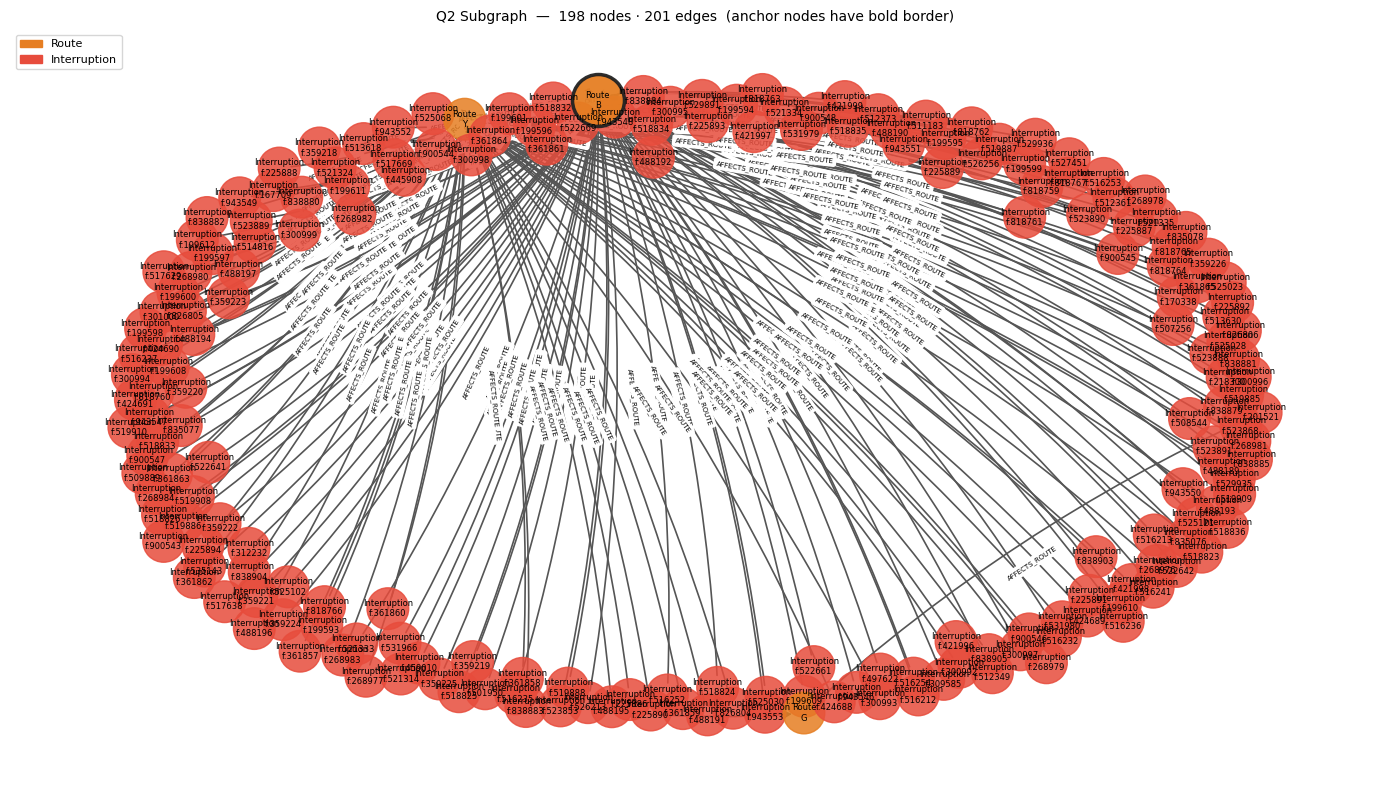


── Step 3b · Text-to-Cypher ─────────────────────────────
  attempts : 1   success: True

  Cypher:
MATCH (i:Interruption:Delay)-[:AFFECTS_ROUTE]->(r:Route:Rail {route_short_name: 'BLUE'})
MATCH (i)-[:AFFECTS_TRIP]->(t:Trip)-[:FOLLOWS]->(rp:RoutePattern)-[:BELONGS_TO]->(r)
MATCH (t)-[:SCHEDULED_AT]->(p:Platform)<-[:CONTAINS]-(s:Station)
WHERE i.end_time IS NULL
RETURN
  s.name AS station,
  s.id AS station_id,
  count(DISTINCT t) AS affected_trips,
  i.severity AS severity,
  i.start_time AS delay_started
ORDER BY affected_trips DESC
LIMIT 20;

  Chain-of-Thought:
**Explanation:**

This query finds all stations currently affected by active delays on the Blue Line by:

1. Matching the active Interruption:Delay node (where `end_time IS NULL`) that affects the Blue Line route
2. Following the delay back through affected trips that follow Blue Line route patterns
3. Finding all platforms where those trips are scheduled
4. Resolving each platform to its containing station
5. Aggregating by

In [21]:
result2 = run_and_display(
    USER_QUERIES[1], 2, db, llm_config, registry, planner, narration_agent
)

---
## Q2 · Comparison Notes

```
TODO: fill in after running

Static pipeline
  mode    :
  sources :
  answer  :

Agentic pipeline
  mode    :
  sources :
  tools   :
  answer  :

Observations:
  -
```

---
---
# Question 3

> *"Is the elevator at Metro Center currently out of service?"*

Same pipeline stages as Q1 — see the Q1 walkthrough above for implementation details.

In [22]:
result3 = run_and_display(
    USER_QUERIES[2], 3, db, llm_config, registry, planner, narration_agent
)


════════════════════════════════════════════════════════
  Q3: Is the elevator at Metro Center currently out of service?
════════════════════════════════════════════════════════

── Step 1 · Planner ─────────────────────────────────────
  domain         : 'accessibility'
  path           : 'text2cypher'
  path_reasoning : 'This is a binary yes/no lookup for current equipment status at a specific station, requiring a direct Cypher query.'
  anchor_notes   : "The query references 'the elevator' generically; the station anchor (Metro Center) is sufficient to locate all elevators there."
  use_gds        : False
  anchors:
    routes         : []
    stations       : ['Metro Center']
    dates          : ['today']
    pathway_nodes  : []
    levels         : []

── Step 2 · Anchor Resolution ───────────────────────────
  'Metro Center'                 → ['STN_A01_C01']
  'today'                        → ['20260413']

── Step 3a · Subgraph ───────────────────────────────────
  (path not ta

---
## Q3 · Comparison Notes

```
TODO: fill in after running

Static pipeline
  mode    :
  sources :
  answer  :

Agentic pipeline
  mode    :
  sources :
  tools   :
  answer  :

Observations:
  -
```

---
## Teardown

In [23]:
db.close()
print("Neo4j connection closed.")

Neo4j connection closed.
